In [22]:
import tensorflow as tf
import keras
import scipy.io
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from Fastkan import FastKAN

In [23]:
number_of_primitives = 3
visible_range = True#Use False to select entire spectrum
include_shadows = True
no_of_epochs = 30
#Visible range of pavia dataset has 66 bands and full spectrum has 103 bands
no_of_bands = 66 if visible_range else 103
output_classes = 9 if include_shadows else 8

# Loading Pavia Univeristy Dataset

In [24]:
hsi = scipy.io.loadmat("PaviaU.mat")
image = hsi["paviaU"]

gt = scipy.io.loadmat("PaviaU_gt.mat")
index = gt["paviaU_gt"]
image  =image[:, :, :66]

print(image.shape)
print(index.shape)

(610, 340, 66)
(610, 340)


In [25]:
#Normalizing the image
max_val = np.max(image)
normalized_image = np.divide(image, max_val)

In [26]:
image_for_training = normalized_image[:,:,:no_of_bands]
print(image_for_training.shape)

(610, 340, 66)


#   Dataset for Training 

In [27]:
x = []
for i in range(len(image_for_training)):
    for j in range(len(image_for_training[0])):
        if (index[i][j] == 0) or (index[i][j] == 9 and (not include_shadows)): #Ignoring all unclassified pixels
            continue
        x.append(image_for_training[i][j])

x = np.asarray(x)
print(x.shape)

(42776, 66)


In [28]:
y = []

for i in range(len(image)):
    for j in range(len(image[0])):
        if index[i][j] == 0 or \
           (index[i][j] == 9 and (not include_shadows)):
            continue

        y.append(index[i][j]-1)

y = np.asarray(y)
y.shape

(42776,)

# Model Defination

In [31]:
tf.keras.backend.clear_session()

# KAN input
inp = keras.layers.Input(shape=(no_of_bands,))

primitive_outputs = []

for i in range(number_of_primitives):

    primitive = FastKAN( [no_of_bands, 1],name=f"primitive_{i+1}"
    )(inp)

    primitive_outputs.append(primitive)
merged = keras.layers.Concatenate(
    name="merged"
)(primitive_outputs)

kan_logits = FastKAN([number_of_primitives,output_classes],name="classifier_kan")(merged)
out = keras.layers.Softmax(
    name="softmax"
)(kan_logits)


model = keras.models.Model(
    inputs=inp,
    outputs=out
)

In [30]:
model.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy", metrics = ["accuracy"]) #Using sparse_categorical_crossentropy because labels are not one-hot-encoded

In [32]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 66)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ primitive_1         │ (None, 1)         │        727 │ input_layer[0][0] │
│ (FastKAN)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ primitive_2         │ (None, 1)         │        727 │ input_layer[0][0] │
│ (FastKAN)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ primitive_3         │ (None, 1)         │        727 │ input_layer[0][0] │
│ (FastKAN)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merged              │ (None, 3)         │          0 │ primitive_1[0][0… │
│ (Concatenate)       │                   │            │ primitive_2[0][0… │
│                     │                   │            │ primitive_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier_kan      │ (None, 9)         │        258 │ merged[0][0]      │
│ (FastKAN)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 9)         │          0 │ classifier_kan[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,439 (9.53 KB)

 Trainable params: 2,439 (9.53 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(x, y, epochs = no_of_epochs)

Epoch 1/30
1337/1337 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6975 - loss: 0.9497
Epoch 2/30
1337/1337 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8001 - loss: 0.5689
Epoch 3/30
1337/1337 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8096 - loss: 0.5248
Epoch 4/30
1337/1337 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8177 - loss: 0.5015
Epoch 5/30
1337/1337 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8233 - loss: 0.4859
Epoch 6/30
1337/1337 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8289 - loss: 0.4730
Epoch 7/30
1337/1337 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8312 - loss: 0.4640
Epoch 8/30
1337/1337 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8331 - loss: 0.4558
Epoch 9/30
1337/1337 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8366 - loss: 0.4481
Epoch 10/30
1337/1337 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8384 - loss: 0.4479
Epoch 11/30
1337/1337 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8428 - loss: 0.4345
Epoch 12/30
1337/1337 ━━━━━━━━

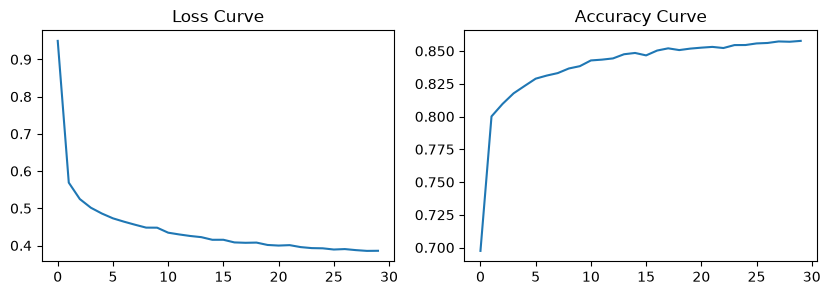

In [33]:
plt.figure(figsize = (10,3))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"])
plt.title("Loss Curve")
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"])
plt.title("Accuracy Curve")
plt.show()

# Plot each learned Filters

In [34]:
wavelength = np.linspace(430, 860, 66) #430 - 860 is range of paviaU dataset and 103 is number of bands
wavelength_int = wavelength.astype(int)
print(wavelength_int)

[430 436 443 449 456 463 469 476 482 489 496 502 509 516 522 529 535 542
 549 555 562 568 575 582 588 595 602 608 615 621 628 635 641 648 654 661
 668 674 681 688 694 701 707 714 721 727 734 740 747 754 760 767 774 780
 787 793 800 807 813 820 826 833 840 846 853 860]


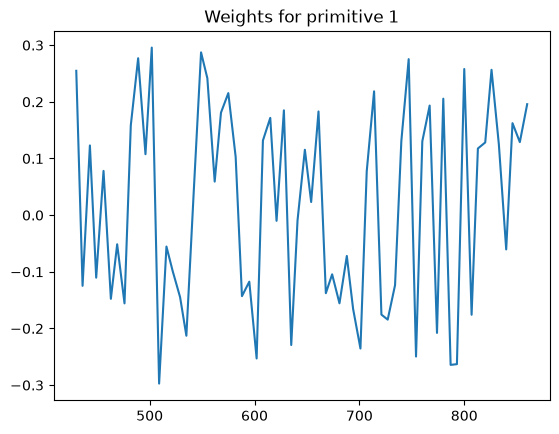

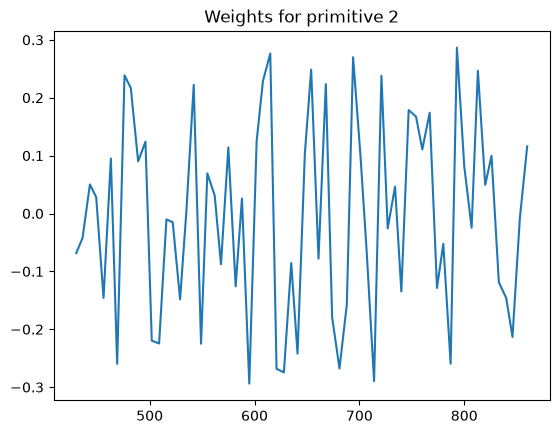

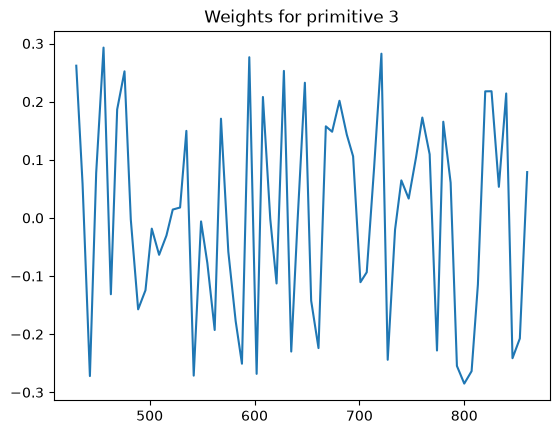

In [35]:
for primitive_no in range(1, number_of_primitives + 1):

    temp = model.get_layer(
        f"primitive_{primitive_no}"
    ).get_weights()[3]

    exec(f"p{primitive_no} = []")

    for i in range(no_of_bands):

        eval(
            f"p{primitive_no}.append(temp[{i}][0])"
        )

    eval(
        f'plt.plot(wavelength_int[:{no_of_bands}], p{primitive_no})'
    )

    eval(
        f'plt.title("Weights for primitive {primitive_no}")'
    )

    plt.show()

In [36]:
for i, layer in enumerate(model.layers):
    if "primitive" in layer.name:
        w = layer.get_weights()[3]
        print(i , layer.name , w[0 , 0])

1 primitive_1 0.25476933
2 primitive_2 -0.068498105
3 primitive_3 0.26183844


In [37]:
for i, v in enumerate(model.trainable_variables):
    print(i, v.name, v.shape)

0 gamma (66,)
1 beta (66,)
2 weight (528, 1)
3 kernel (66, 1)
4 bias (1,)
5 gamma (66,)
6 beta (66,)
7 weight (528, 1)
8 kernel (66, 1)
9 bias (1,)
10 gamma (66,)
11 beta (66,)
12 weight (528, 1)
13 kernel (66, 1)
14 bias (1,)
15 gamma (3,)
16 beta (3,)
17 weight (24, 9)
18 kernel (3, 9)
19 bias (9,)


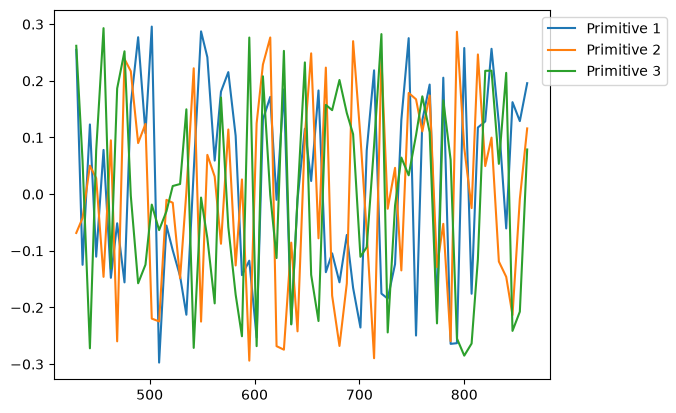

In [38]:
for primitive_no in range(1, number_of_primitives+1):

    eval(
        f'plt.plot(wavelength_int[:{no_of_bands}], '
        f'p{primitive_no}, '
        f'label="Primitive {primitive_no}")'
    )

plt.legend(bbox_to_anchor=(1.25,1))

plt.show()

In [40]:
model_name = (
    f'{no_of_bands}bands_'f'{number_of_primitives}primitives_' f'{"with_shadow" if include_shadows else "without_shadow"}_' f'fastkan_random_init')

In [41]:
print(model_name)

66bands_3primitives_with_shadow_fastkan_random_init


In [43]:
model.save_weights(f"{model_name}.weights.h5")

#Generate Image

In [ ]:
def predict_image():

    layer_name = "merged"

    intermediate_model = keras.models.Model(
        inputs=model.input,
        outputs=model.get_layer(layer_name).output)
    x_pred = []

    for i in range(len(image_for_training)):
        for j in range(len(image_for_training[0])):
            x_pred.append(image_for_training[i][j])

    x_pred = np.asarray(x_pred)
    print("Prediction Input Shape:", x_pred.shape)
    print("Predicting...")

    prediction = intermediate_model.predict( x_pred,verbose=1)
    predicted_image_array = []
    for i in prediction:
        predicted_image_array.append(i)

    predicted_image = []

    pixel = 0

    while pixel < len(predicted_image_array):

        temp = []

        for _ in range(len(image[0])):

            temp.append(
                predicted_image_array[pixel]
            )

            pixel += 1

        predicted_image.append(temp)

    return np.asarray(predicted_image)


def normalize_images(predicted_image, channels):

    max_val = np.max(predicted_image)

    min_max_normalized_image = predicted_image / max_val

    for i in range(1, number_of_primitives + 1):

        exec(
            f"min_max_channel{i} = min_max_normalized_image[:,:,{i-1}]"
        )

    for i in range(1, number_of_primitives + 1):

        exec(
            f"channel{i} = predicted_image[:,:,{i-1}]")

        exec(
            f"channel{i}_max = np.max(np.abs(channel{i}))")

        exec(
            f"normalized_channel{i} = channel{i}/channel{i}_max")

    clipped_image = np.clip(predicted_image,0,1)

    for i in range(1, number_of_primitives + 1):

        exec(
            f"clipped{i} = clipped_image[:,:,{i-1}]"
        )

    normalized_images = []

    eval(
        f'normalized_images.append(('
        f'min_max_channel{channels[0]},'
        f'min_max_channel{channels[1]},'
        f'min_max_channel{channels[2]}'
        f'))'
    )

    eval(
        f'normalized_images.append(('
        f'normalized_channel{channels[0]},'
        f'normalized_channel{channels[1]},'
        f'normalized_channel{channels[2]}'
        f'))'
    )

    eval(
        f'normalized_images.append(('
        f'clipped{channels[0]},'
        f'clipped{channels[1]},'
        f'clipped{channels[2]}'
        f'))'
    )

    return [ np.dstack(normalized_images[0]),np.dstack(normalized_images[1]),np.dstack(normalized_images[2])]

Prediction Input Shape: (207400, 66)
Predicting...
6482/6482 ━━━━━━━━━━━━━━━━━━━━ 4s 660us/step


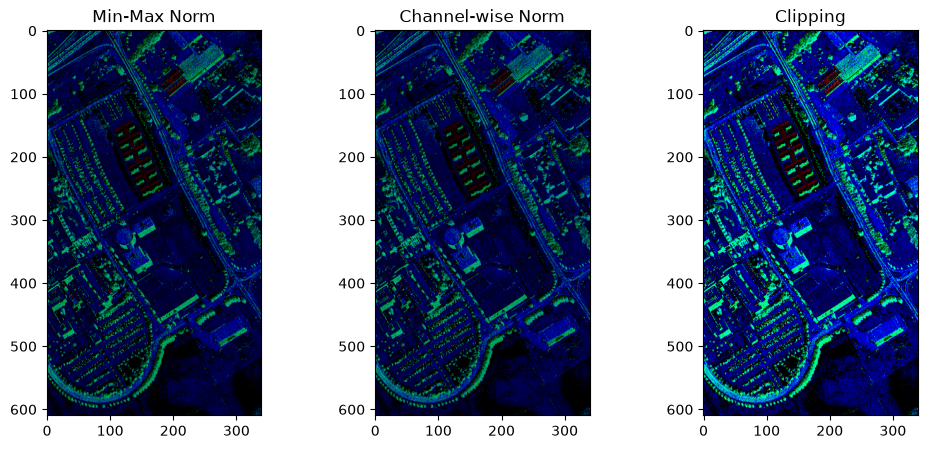

In [49]:
channels = [1, 2, 3]

predicted_image = predict_image()

normalized_images = normalize_images(
    predicted_image,
    channels
)
plt.figure(figsize=(12,5))

plt.subplot(1, 3, 1)
plt.imshow(normalized_images[0])
plt.title("Min-Max Norm")

plt.subplot(1, 3, 2)
plt.imshow(normalized_images[1])
plt.title("Channel-wise Norm")

plt.subplot(1, 3, 3)
plt.imshow(normalized_images[2])
plt.title("Clipping")

plt.show()